# 1G+1G Retention Probability Grid

Compute and visualize $P_{\rm ret}(q, \chi_{\rm max}, v_{\rm esc})$ for 1G+1G BBH mergers
using `BBHRetentionProbability1G1G`. Reproduces Figure 2 of Islam, Wadekar & Kritos (2026, arXiv:2603.10170).

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

from gwGenealogy.core import BBHRetentionProbability1G1G
from gwGenealogy.utils import set_rcparams
import numpy as np
import matplotlib.pyplot as plt

set_rcparams()

lal.MSUN_SI != Msun


## HLZ kick model

Sweep $q \in [1, 10]$, $\chi_{\rm max} \in [0.01, 1]$ at four escape velocities.

In [2]:
grid_hlz = BBHRetentionProbability1G1G(
    q_values=np.linspace(1, 10, 50),
    chi_max_values=np.linspace(0.01, 1, 50),
    v_esc_values=[50, 100, 200, 500],
    kick_models=['hlz'],
    n_samples=10000, seed=42)
print(grid_hlz)
results_hlz = grid_hlz.compute(verbose=True)

BBHRetentionProbability1G1G(q=[1.0,10.0]x50, chi=[0.01,1.00]x50, v_esc=[np.float64(50.0), np.float64(100.0), np.float64(200.0), np.float64(500.0)], models=['hlz'], n=10000)


  250/2500 grid points done


  500/2500 grid points done


  750/2500 grid points done


/Users/tousifislam/Research/projects/stupid/refactor_gwModels/gwModels/gwModels/remnants/HBR_mass_spin.py:187: RuntimeWarning: invalid value encountered in sqrt
  chi_final = np.sqrt(term1 + term2 + term3) / (1.0 + small_q)**2


...

  1500/2500 grid points done


  1750/2500 grid points done


  2000/2500 grid points done


  2250/2500 grid points done


  2500/2500 grid points done


/Users/tousifislam/Research/projects/stupid/gwGenealogy/gwGenealogy/core/retention.py:235: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


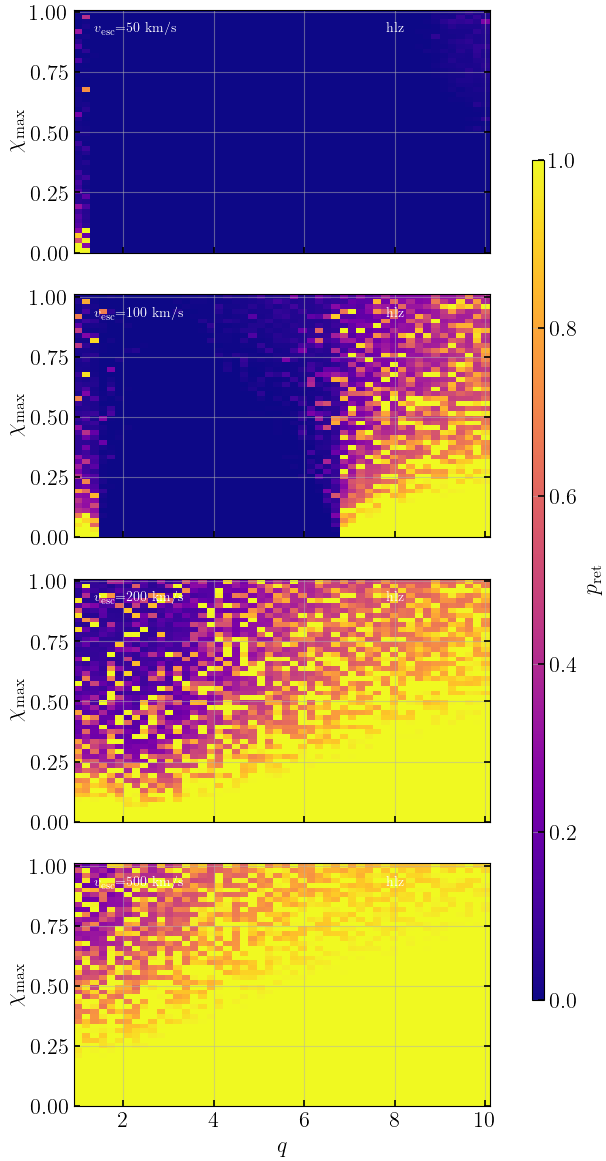

In [3]:
fig, axes = grid_hlz.plot_heatmap_all_vesc()
plt.show()

### Single panel: $v_{\rm esc} = 200$ km/s

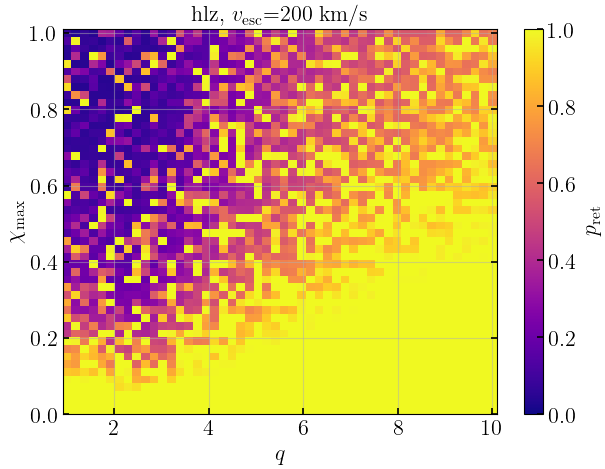

In [4]:
fig, ax, im = grid_hlz.plot_heatmap('hlz', 200)
fig.colorbar(im, ax=ax, label=r'$p_{\rm ret}$')
plt.show()

## HLZ vs gwModel comparison

Run both kick models on the same grid with shared isotropic angles.
The `plot_heatmap_all_vesc()` method shows v_esc rows x model columns.

**Note:** gwModel uses a normalizing flow that evaluates per-sample, so
we use a coarser grid (10x10) with fewer samples (1000) here for speed.

In [5]:
grid_both = BBHRetentionProbability1G1G(
    q_values=np.linspace(1, 10, 10),
    chi_max_values=np.linspace(0.01, 1, 10),
    v_esc_values=[50, 100, 200, 500],
    kick_models=['hlz', 'gwmodel'],
    n_samples=1000, seed=42)
print(grid_both)
results_both = grid_both.compute(verbose=True)

BBHRetentionProbability1G1G(q=[1.0,10.0]x10, chi=[0.01,1.00]x10, v_esc=[np.float64(50.0), np.float64(100.0), np.float64(200.0), np.float64(500.0)], models=['hlz', 'gwmodel'], n=1000)


  10/100 grid points done


  20/100 grid points done


  30/100 grid points done


  40/100 grid points done


...

  60/100 grid points done


  70/100 grid points done


  80/100 grid points done


  90/100 grid points done


  100/100 grid points done


/Users/tousifislam/Research/projects/stupid/gwGenealogy/gwGenealogy/core/retention.py:235: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


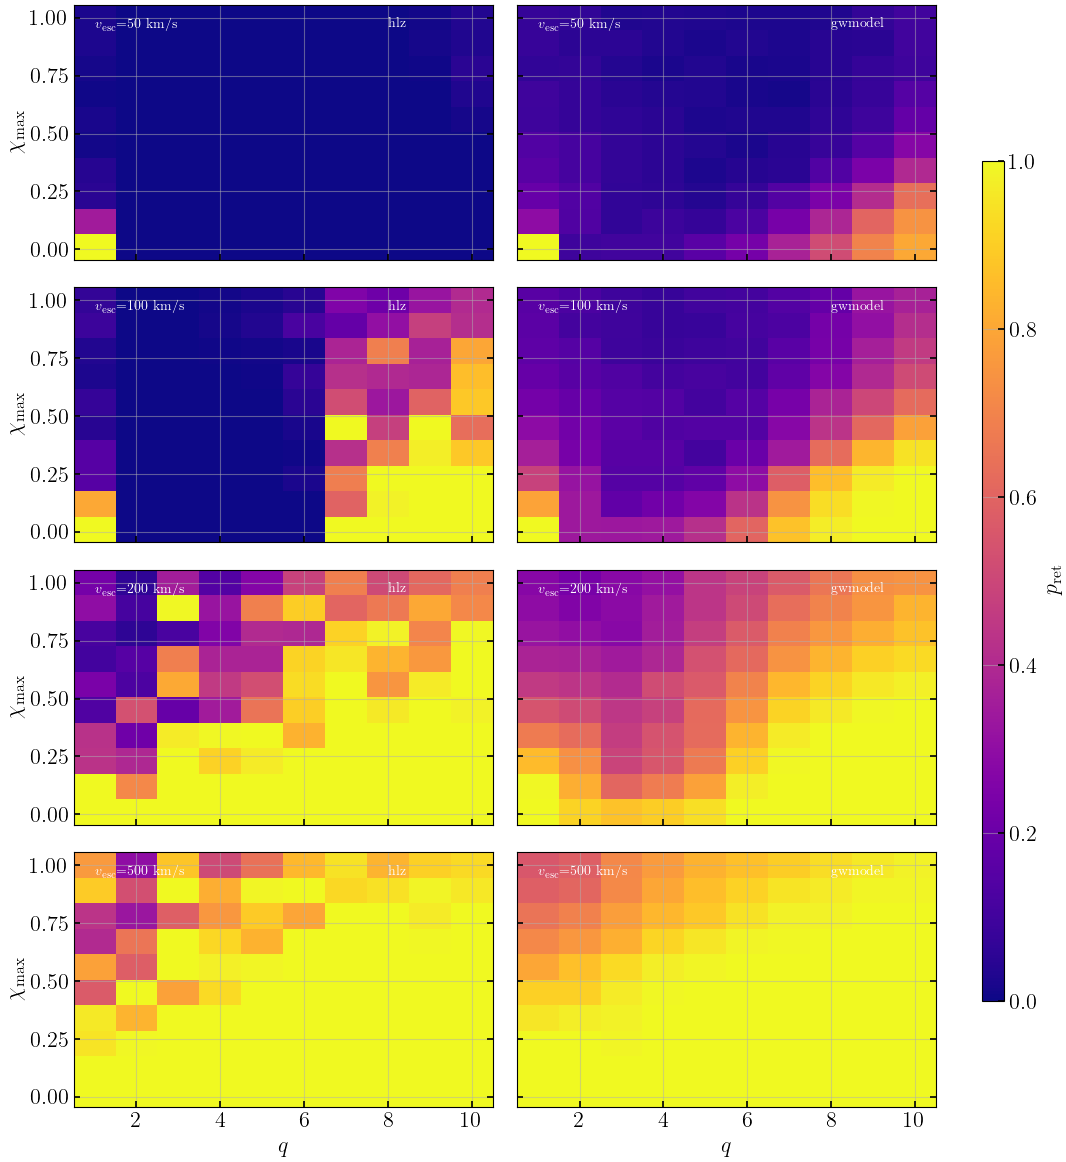

In [6]:
fig, axes = grid_both.plot_heatmap_all_vesc()
plt.show()